In [ ]:
import marimo as mo

<h1 style="text-align: center;"><strong>Python Programming for Machine Learning</strong></h1>

<h3 style="text-align: center;"><strong>L2 — Intro to ML Projects</strong></h3>

<div style="text-align: center;">Summer Term 2026 · Stefaan Hessmann</div>

## Agenda

Today's lecture is a **overview** of an ML project. Most of
the content below gets explored in depth in a later lecture.

1. **Motivation** — neural nets are universal approximators. So why is real ML hard?
2. **Six components of an ML project** — Data, Model, Training, Eval, Scripts, Tests.
3. **Setting up the environment** — `pyproject.toml`, `uv`.
4. **Project layout** — library vs. scripts vs. tests.
5. **Data** — `Dataset`, transforms, `DataLoader`.
6. **Model** — one file, decoupled.
7. **Training** — the optimisation loop.
8. **Evaluation** — accuracy evaluation.
9. **Entry scripts** — `python -m scripts.train`.
10. **Cross-cutting** — config, reproducibility, agent skills.
11. **Tests** — `pytest`.
12. **Landing in an unfamiliar repo** — nanochat.
13. **Recap & bridge to L3.**

Running example: `mnist_proj/` — a tiny MNIST classifier.

## 1. Neural networks are universal function approximators

- A sufficiently wide neural net can approximate **any** continuous
  function on a compact domain (Cybenko 1989, Hornik 1991).
- In ML language: given enough data, we can learn **any** input → output
  mapping, including very complex distributions.

So in theory, training a model is "just":

$$
\theta^* = \arg\min_\theta\; \mathbb{E}_{(x,y) \sim p_{\text{data}}}
\big[\, \mathcal{L}\!\big(f_\theta(x),\, y\big)\,\big]
$$

### …so why isn't ML one Python file?

In practice you need to:

- **get the data**
- **define the model**
- **run the training**
- **measure progress**
- **reproduce the result**
- **share it**

## 2. The components of an ML project

Six recurring boxes, plus three cross-cutting concerns:

| # | Box | What it does |
|---|---|---|
| 1 | **Data** | download, clean, split, preprocess |
| 2 | **Model** | architecture, parameters |
| 3 | **Training** | optimisation loop |
| 4 | **Evaluation** | metrics on held-out data |
| 5 | **Entry scripts** | the things you run from a shell |
| 6 | **Tests** | catch silent breakages on refactor |

Cross-cutting:

- **Configuration** — hyperparams, paths, flags. Where they live matters.
- **Reproducibility / artifacts** — run dirs, checkpoints, logs.
- **Agent skills** — `AGENTS.md`, `CLAUDE.md`, `.claude/skills/`.

> These boxes are not Python-specific or PyTorch-specific. The same
> components show up in JAX repos, in Julia ML projects, in classical
> computer-vision pipelines from 2015. The names and file layouts vary;
> the components don't.

```text
┌─────────────────────────────────────────────┐
│                 5. Scripts                  │   ← entry points (CLI, glue)
└────┬───────────┬───────────┬───────────┬────┘
     │           │           │           │
     ▼           ▼           ▼           ▼
┌────┴────┐ ┌────┴────┐ ┌────┴────┐ ┌────┴────┐
│ 1. Data │→│ 2. Model│→│ 3. Train│→│ 4. Eval │
└─────────┘ └─────────┘ └─────────┘ └─────────┘

Underneath: 6. Tests · Config · Reproducibility · Agent skills
```

The arrows from Scripts down are *control* — `scripts/train.py`
builds each library object in turn (and `scripts/predict.py`
reaches into Data, Model, and Eval). The arrows along the bottom
row are *data* — a batch flows through Data → Model → Train →
Eval inside one step.

## 3. Setting up the environment

Before any code runs, you need:

1. **Project folder**. We use `mnist_project`.
2. **Definition of project requirements**:
   `pyproject.toml` is a single source of truth for dependencies + package metadata. (Old `setup.py` / `requirements.txt`
   patterns still work but are no longer the default.)
3. **A virtual environment**. (Do not use your system Python.)

### `mnist_proj/pyproject.toml`

```toml
[project]
name = "mnist_proj"
version = "0.1.0"
requires-python = ">=3.11"
dependencies = [
    "torch>=2.2",
    "kagglehub",
    "pillow",
    "numpy",
    "matplotlib",
    "tqdm",
]

[project.optional-dependencies]
dev = ["pytest"]
```

### One-time setup

Tools:

- `uv` (fast, written in Rust) — what we'll use.
- `pip` + `venv` — classic, works everywhere.
- `conda` / `mamba` — common in scientific computing.

```bash
cd mnist_proj
uv venv                      # create .venv/
source .venv/bin/activate
uv pip install -e .          # install our project + dependencies
uv pip install -e ".[dev]"   # also pytest
```

## 4. Project layout

```text
mnist_proj/
├── pyproject.toml          dependencies, package metadata
├── README.md               what is this, how do I run it
├── AGENTS.md               guidance for AI agents
├── mnist_proj/             ← library code (importable)
│   ├── __init__.py
│   ├── data.py             ← Box 1: Data / ETL   (dataset + transforms)
│   ├── model.py            ← Box 2: Model        (architecture)
│   ├── train.py            ← Box 3: Training     (training fn)
│   └── eval.py             ← Box 4: Evaluation   (accuracy fn)
├── scripts/                ← Box 5: Entry scripts (CLI)
│   ├── train.py              python -m scripts.train
│   └── predict.py            python -m scripts.predict
├── tests/                  ← Box 6: Tests
│   └── test_model.py
└── runs/                     run artifacts (created at first train)
```

### Library vs. scripts — the most important convention

| Library code (`mnist_proj/`) | Entry scripts (`scripts/`) |
|---|---|
| **Importable** — `import mnist_proj.model` works | **Runnable** — `python -m scripts.train` |
| Functions and classes | Glue code: parse → call library → save |
| No side effects on import | no imports from script files |
| No `argparse` at module level | All `argparse`/CLI parsing here |
| Reused by tests, scripts, notebooks | One file per "thing you run" |

Most beginner repos collapse these into one giant `train.py`. **Don't.**

## 5. Data — *(Box 1: Data)*

Most of an ML project's pain lives here. We split the data layer into
three responsibilities:

1. **Get the raw data onto disk.** A folder of files we can inspect.
2. **`Dataset`** — knows how to fetch *one* sample by index.
3. **`DataLoader`** — batches samples, shuffles, parallelises.

> **L1 callback.** Both interfaces are the dunder/iterator protocol
> from L1. `Dataset` is just a class that implements `__len__` /
> `__getitem__` (the same pattern as `Vector` or `CountUp` from L1).
> `DataLoader` is the same `__iter__` / `__next__` machinery as the
> tiny `DataLoader` class we wrote by hand in L1 — PyTorch's version
> just adds shuffling, batching and multi-process workers.

> **Forward pointer.** We treat tensors as opaque NumPy-like objects
> today. In **L3** (Acceleration frameworks) we open them up — what
> primitive ops compose into `to_tensor`, broadcasting, indexing,
> and how they run on a GPU. In **L9** (GPUs) we'll come back to
> `DataLoader` performance — workers, prefetch, pin-memory.

### MNIST

<img src="public/mnist.png" width="700">

- 70 000 grayscale images of handwritten digits, 28 × 28 px each
- the *"Hello World"* of deep-learning vision
- today's task: classify each image into one of 10 digits (0–9)

### Imports and settings

In [2]:
# Imports + constants that everything below uses.
import shutil
from pathlib import Path

import kagglehub
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader

KAGGLE_DATASET = "scolianni/mnistasjpg"
# The labelled set has ~42 000 images. Split sizes (deterministic by sorted filename):
TRAIN_SIZE = 30_000
VAL_SIZE = 6_000
# test = whatever is left (~6 000)
SPLITS = ("train", "val", "test")
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

ImportError: cannot import name 'get_web_endpoint' from 'kagglesdk.kaggle_env' (C:\Users\jrzel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\kagglesdk\kaggle_env.py)

### Step 1 — Download

A small function that fetches `scolianni/mnistasjpg` from Kaggle once
into `data/mnist/`, and is a no-op on subsequent calls.

In [ ]:
def download_mnist(data_path="data/mnist"):
    """Download MNIST JPGs to data_path (no-op if already present)."""
    data_path = Path(data_path)
    if data_path.exists() and any(data_path.iterdir()):
        return data_path
    cache = kagglehub.dataset_download(KAGGLE_DATASET)
    data_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.move(str(cache), str(data_path))
    return data_path

data_path = download_mnist()
print(f"data is at: {data_path}")

data is at: data/mnist


### Step 2 — Inspect the folder

Before writing any abstraction, look at the folder. The Kaggle
dataset ships MNIST as plain JPG files organised by digit:

In [ ]:
base = data_path / "trainingSet" / "trainingSet"
print(f"top-level:           {data_path}")
print(f"contents:            {sorted(p.name for p in data_path.iterdir())}")
print(f"\nclass folders inside trainingSet/trainingSet/:")
for digit_dir in sorted(base.iterdir()):
    files = sorted(digit_dir.glob("*.jpg"))
    examples = [f.name for f in files[:2]]
    print(f"  {digit_dir.name}/  {len(files):>5} files  e.g. {examples}")

top-level:           data/mnist
contents:            ['testSample', 'testSet', 'testSet.tar.gz', 'trainingSample', 'trainingSet', 'trainingSet.tar.gz']

class folders inside trainingSet/trainingSet/:
  0/   4132 files  e.g. ['img_1.jpg', 'img_10007.jpg']
  1/   4684 files  e.g. ['img_0.jpg', 'img_1000.jpg']
  2/   4177 files  e.g. ['img_10000.jpg', 'img_10011.jpg']
  3/   4351 files  e.g. ['img_10004.jpg', 'img_10016.jpg']
  4/   4072 files  e.g. ['img_10020.jpg', 'img_10023.jpg']
  5/   3795 files  e.g. ['img_10001.jpg', 'img_10008.jpg']
  6/   4137 files  e.g. ['img_10005.jpg', 'img_10021.jpg']
  7/   4401 files  e.g. ['img_10015.jpg', 'img_10019.jpg']
  8/   4063 files  e.g. ['img_10.jpg', 'img_10024.jpg']
  9/   4188 files  e.g. ['img_100.jpg', 'img_10002.jpg']


### Step 3 — Read images from disk

Two helpers:

- **`get_image`** returns *one* image given a digit and an index. PIL
  opens JPGs into a `PIL.Image.Image` — *not* a torch tensor. We'll
  fix that with a transform later.
- **`get_mnist_jpg_paths`** walks every digit folder and returns all
  `(paths, labels)` pairs, sorted by filename so the order is
  reproducible. The `Dataset` class in the next step will reuse it.

In [ ]:
def get_image(data_path, digit, idx):
    """Return (PIL image, label) for the idx-th image of given digit."""
    files = sorted((Path(data_path) / "trainingSet" / "trainingSet" / str(digit)).glob("*.jpg"))
    return Image.open(files[idx]), digit

def get_mnist_jpg_paths(data_path):
    """Return (paths, labels) for every JPG in the dataset, sorted by filename."""
    base = Path(data_path) / "trainingSet" / "trainingSet"
    paths, labels = [], []
    for digit in range(10):
        for img in sorted((base / str(digit)).glob("*.jpg")):
            paths.append(img)
            labels.append(digit)
    order = sorted(range(len(paths)), key=lambda i: paths[i].name)
    return [paths[i] for i in order], [labels[i] for i in order]

_img, _label = get_image(data_path, digit=7, idx=0)
print(f"label: {_label}")
print(f"type:  {type(_img).__name__}")
print(f"size: {_img.size}")

_all_paths, _all_labels = get_mnist_jpg_paths(data_path)
print(f"\ntotal images: {len(_all_paths)}")
print(f"first path:   {_all_paths[0]}")
_img

label: 7
type:  JpegImageFile
size: (28, 28)

total images: 42000
first path:   data/mnist/trainingSet/trainingSet/1/img_0.jpg


### Step 4 — Wrap it in a `Dataset` class

Steps 1–3 work, but we have three loose pieces. A class lets us
bundle them together and exposes a single object that follows the
`__len__` / `__getitem__` protocol PyTorch's `DataLoader` expects.

Two design choices worth flagging:

- **No `Dataset` inheritance.** PyTorch's `DataLoader` only needs
  `__len__` and `__getitem__` — it duck-types on the protocol.
  Inheriting from `torch.utils.data.Dataset` is convention, not
  requirement. Our class is plain Python.
- **The class reuses the helpers from steps 1 and 3.** `download()`
  delegates to `download_mnist`, and path discovery delegates to
  `get_mnist_jpg_paths`. The class itself just adds split slicing
  and the `__len__` / `__getitem__` protocol on top.

The constructor also takes a list of **transforms** — callables
applied in order to each sample. With `transforms=None` (the
default), indexing returns a raw PIL image.

In [ ]:
class MNIST:
    """Loads MNIST from a folder of JPGs.

    A plain Python class — *not* a subclass of torch.utils.data.Dataset.

    Args:
        split: one of "train", "val", "test".
        transforms: list of callables applied in order to each sample.
            None or [] means no transforms — __getitem__ returns a PIL image.
    """

    def __init__(self, data_path="data/mnist", split="train", transforms=None):
        if split not in SPLITS:
            raise ValueError(f"split must be one of {SPLITS}, got {split!r}")
        self.data_path = Path(data_path)
        self.split = split
        self.transforms = transforms or []

        self.download()
        paths, labels = get_mnist_jpg_paths(self.data_path)

        train_end, val_end = TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE
        if split == "train":
            self.paths, self.labels = paths[:train_end], labels[:train_end]
        elif split == "val":
            self.paths, self.labels = paths[train_end:val_end], labels[train_end:val_end]
        else:  # "test"
            self.paths, self.labels = paths[val_end:], labels[val_end:]

    def download(self):
        """Delegate to the module-level download_mnist."""
        download_mnist(self.data_path)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        sample = Image.open(self.paths[idx])
        for t in self.transforms:
            sample = t(sample)
        return sample, self.labels[idx]

In [ ]:
# No transforms → __getitem__ returns the raw PIL image, just like Image.open.
dataset = MNIST(split="train")
sample, sample_label = dataset[0]
print(f"len:   {len(dataset)}")
print(f"type:  {type(sample).__name__}")  # PIL image — *not* a torch tensor
print(f"label: {sample_label}")
sample

len:   30000
type:  JpegImageFile
label: 1


### Step 5 — Transforms

A transform is just a function. We need at least one to convert PIL
→ tensor. We can stack more for **data augmentation**: random,
label-preserving distortions (rotations, small shifts, scaling…) so
the model sees more variety per epoch and learns features robust to
small perturbations.

We define two:

- **`to_tensor`** — PIL → normalised float tensor of shape `(1, 28, 28)`.
- **`random_augment`** — PIL → PIL with random rotation + pixel shift.

For training we'll chain `[random_augment, to_tensor]`. For val / test
we use just `[to_tensor]` — eval metrics need to be deterministic.

In [ ]:
def to_tensor(img):
    """PIL grayscale image → normalised tensor of shape (1, 28, 28)."""
    arr = np.asarray(img, dtype=np.float32) / 255.0
    t = torch.from_numpy(arr).unsqueeze(0)
    return (t - MNIST_MEAN) / MNIST_STD

In [ ]:
import random


def random_augment(img):
    """PIL → PIL with random ±15° rotation and ±2 px shift."""
    img = img.rotate(random.uniform(-15, 15), resample=Image.BILINEAR)
    dx, dy = random.randint(-2, 2), random.randint(-2, 2)
    # PIL affine: output[x,y] = input[a*x+b*y+c, d*x+e*y+f]
    return img.transform(img.size, Image.AFFINE, (1, 0, -dx, 0, 1, -dy))

#### `Dataset` with `transforms=[to_tensor]`

Now `__getitem__` returns a tensor, ready for the model.

In [ ]:
dataset_t = MNIST(split="train", transforms=[to_tensor])
img_t, label_t = dataset_t[0]
print(f"type:  {type(img_t).__name__}")
print(f"shape: {tuple(img_t.shape)}, dtype: {img_t.dtype}")
print(f"label: {label_t}")

type:  Tensor
shape: (1, 28, 28), dtype: torch.float32
label: 1


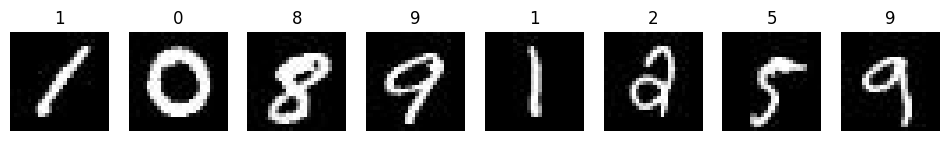

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, idx in zip(axes, range(8)):
    img, label = dataset_t[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(label)
    ax.axis("off")
fig

#### `Dataset` with `transforms=[random_augment, to_tensor]`

Same indices as above — but each call produces a different sample,
because the augmentation is random.

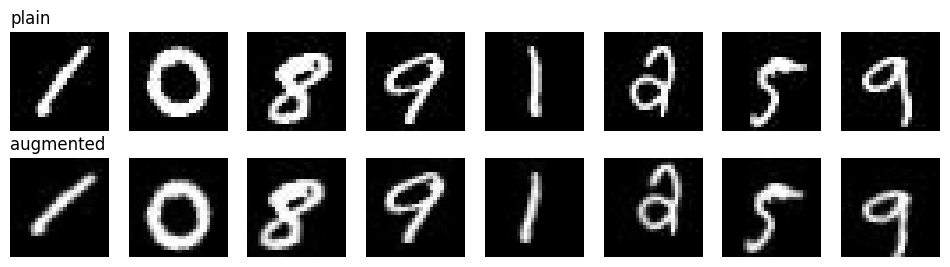

In [ ]:
dataset_aug = MNIST(split="train", transforms=[random_augment, to_tensor])

fig_aug, axes_aug = plt.subplots(2, 8, figsize=(12, 3))
for _i, _ax in enumerate(axes_aug[0]):
    _img, _ = dataset_t[_i]
    _ax.imshow(_img.squeeze(), cmap="gray")
    _ax.axis("off")
for _i, _ax in enumerate(axes_aug[1]):
    _img, _ = dataset_aug[_i]
    _ax.imshow(_img.squeeze(), cmap="gray")
    _ax.axis("off")
axes_aug[0, 0].set_title("plain", loc="left")
axes_aug[1, 0].set_title("augmented", loc="left")
fig_aug

### Step 6 — A toy `DataLoader`, by hand

Before we use PyTorch's, let's write a tiny version. A dataloader's
job: iterate the dataset in chunks and **stack individual samples
into batched tensors**. Models want one `(batch, 1, 28, 28)` tensor,
not 128 separate `(1, 28, 28)` tensors.

A generator function expresses this in five lines.

In [ ]:
def toy_dataloader(dataset, batch_size):
    """Yield (images, labels) batches; drop the last partial batch."""
    n = len(dataset)
    for start in range(0, n - batch_size + 1, batch_size):
        imgs, labels = [], []
        for i in range(start, start + batch_size):
            img, label = dataset[i]
            imgs.append(img)
            labels.append(label)
        yield torch.stack(imgs), torch.tensor(labels)

In [ ]:
_imgs_b, _labels_b = next(iter(toy_dataloader(dataset_t, batch_size=4)))
print(f"batch images: {tuple(_imgs_b.shape)}")
print(f"batch labels: {tuple(_labels_b.shape)}, values: {_labels_b.tolist()}")

batch images: (4, 1, 28, 28)
batch labels: (4,), values: [1, 0, 8, 9]


### Step 7 — PyTorch's `DataLoader` and the splits

PyTorch's `DataLoader` is what `toy_dataloader` would grow into:
same iterator protocol, plus shuffling, multi-process workers,
`drop_last`, custom collate, pin-memory.

Three datasets, three dataloaders. **Only the training dataset
gets `random_augment`** — val / test stay deterministic.

#### Why three splits?

- **train** — what the optimiser sees. The model fits this.
- **val** — held out during training. Watch val accuracy each
  epoch to decide when to stop, what hyperparameters to try.
- **test** — touched only at the very end, to report the final
  number. If you tune on the test set, you no longer have a
  test set.

> **Note.** MNIST in this notebook has *fixed* splits — everyone
> gets the same train / val / test by sorting filenames
> and slicing. In real projects you usually start from one big
> dataset and create *random subsets* — a typical default is
> **80 / 10 / 10**.

In [ ]:
train_ds = MNIST(split="train", transforms=[random_augment, to_tensor])
val_ds   = MNIST(split="val",   transforms=[to_tensor])
test_ds  = MNIST(split="test",  transforms=[to_tensor])
print(f"train: {len(train_ds)} samples (augmented)")
print(f"val:   {len(val_ds)} samples")
print(f"test:  {len(test_ds)} samples")

train: 30000 samples (augmented)
val:   6000 samples
test:  6000 samples


In [ ]:
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=128, shuffle=False)

images_b, labels_b = next(iter(train_dl))
print(f"batch images: {tuple(images_b.shape)}")
print(f"batch labels: {tuple(labels_b.shape)}")

batch images: (128, 1, 28, 28)
batch labels: (128,)


## 6. Model — *(Box 2: Model)*

**One file. No data loading, no training, no logging.** You can import
the class, instantiate it, and call it on a random tensor with no
training infrastructure at all. This decoupling is what lets the model
be unit-tested.

### Why subclass `nn.Module`?

A model has two things the rest of the project needs:

- **Parameters** — the tensors that get updated by the optimiser.
- **A forward pass** — how those parameters are combined with an input
  to produce an output.

`nn.Module` is the bookkeeping. When you assign `self.net = nn.Linear(...)`
in `__init__`, the base class **registers every contained tensor as a
parameter**, so `model.parameters()` returns the full list (which is
what the optimiser iterates over) and `model.state_dict()` knows what
to save / load. It also handles `model.to(device)` recursively, train
vs. eval mode (`model.train()` / `model.eval()`), and gradient
tracking. Writing all of that by hand for every model would be
error-prone and noisy — `nn.Module` is the standard interface every
PyTorch tool (DataLoader, `torch.save`, `torch.compile`, `torchvision`,
Hugging Face) expects.

In [ ]:
# mnist_proj/model.py
import torch.nn as nn


class SimpleClassifier(nn.Module):
    def __init__(self, image_size=28, hidden=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(image_size * image_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Sanity-check: forward pass on random input. No data, no training.
_model = SimpleClassifier()
_x = torch.randn(4, 1, 28, 28)
_logits = _model(_x)
print(f"logits shape: {tuple(_logits.shape)}")  # (4, 10) — one row of class scores per image

logits shape: (4, 10)


> **L1 callback.** `SimpleClassifier` subclasses `nn.Module` and
> forwards its constructor with `super().__init__()` — the exact
> inheritance pattern from the `Parent` / `Child` example in L1.
> Calling `model(x)` invokes `nn.Module.__call__`, which in turn
> calls our `forward()`. That's the same `__call__` dunder you saw
> in L1, just one layer deep.

> **Forward pointer.** A two-layer MLP is the world's simplest
> deep model. **L4** (DL intro) covers what makes deep nets
> actually deep — initialisation, normalisation, residuals.
> **L6 / L7** replace this MLP with a small language model and
> a Transformer, which is the same `nn.Module` pattern with a
> more interesting `forward()`.

## 7. Training — *(Box 3: Training)*

Every training script you will ever read has the same skeleton:

```text
build_dataloader()
build_model()
build_optimizer()
for step in range(max_steps):
    batch = next(dataloader)
    loss = model(batch).loss
    loss.backward()
    optimizer.step()
    if step % log_every == 0: log()
    if step % eval_every == 0: eval()
    if step % save_every == 0: checkpoint()
```

The training loop is **boring on purpose.** Cleverness lives in the
model, the data pipeline, and the eval — not in the loop.

> **Forward pointer.** Today we treat `loss.backward()` and
> `optimizer.step()` as black boxes. **L5** (Backprop / autograd)
> opens them up: how PyTorch builds the computation graph, what
> a gradient actually is, and why the abstraction is sometimes
> leaky enough that you need to know what's underneath.

In [ ]:
# mnist_proj/train.py
from tqdm import tqdm


def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    running_loss, n_batches = 0.0, 0
    for images, labels in tqdm(dataloader, desc="train", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        prediction = model(images)
        loss = loss_fn(prediction, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1
    return running_loss / max(n_batches, 1)


def train(model, dataloader, val_dataloader=None, epochs=1, lr=1e-3, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        epoch_loss = train_one_epoch(model, dataloader, optimizer, loss_fn, device)
        msg = f"epoch {epoch + 1}/{epochs} — loss {epoch_loss:.4f}"
        if val_dataloader is not None:
            pass # add validation metrics here
        print(msg)
    return model

In [ ]:
# Train for one epoch — ~30 s on CPU. Val accuracy is reported each epoch.
model = SimpleClassifier()
model = train(model, train_dl, val_dataloader=val_dl, epochs=1)


train:  99%|████████████████████████████████████████████████████████▎| 232/235 [00:03<00:00, 72.35it/s]


epoch 1/1 — loss 0.8058 — val acc 0.9198


## 8. Evaluation — *(Box 4: Evaluation)*

How we know the thing works. Two flavours:

- **Intrinsic eval** — loss / accuracy on a held-out split.
  Cheap, runs during training. Tells us if optimisation is working.
- **Downstream eval** — does the model do its job? For an MNIST
  classifier that's just classification accuracy; for an LLM it's
  MMLU, HumanEval, and so on.

For our project we do plain accuracy on the test split.

> **L1 callback.** The `accuracy` function is decorated with
> `@torch.no_grad()` — exactly the decorator pattern from L1
> (a function that wraps another function and changes its
> behaviour). Here it tells PyTorch not to build the autograd
> graph during evaluation, which makes inference faster and
> saves memory.

> **Forward pointer.** *Why* `no_grad()` matters becomes clear
> in **L5** (autograd) — it's the decorator that decides whether
> the engine records operations for backprop.

In [ ]:
# mnist_proj/eval.py
@torch.no_grad()
def accuracy(model, dataloader, device=None):
    device = device or next(model.parameters()).device
    model.eval()
    correct, total = 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.numel()
    return correct / max(total, 1)

In [ ]:
acc = accuracy(model, test_dl)
print(f"test accuracy: {acc:.4f}")

test accuracy: 0.9143


## 9. Entry scripts — *(Box 5: Entry scripts)*

Library code lives under `mnist_proj/`. Entry scripts live under
`scripts/`. Each script:

1. parses CLI arguments,
2. calls into the library,
3. writes results to disk.

### `scripts/train.py`

```python
from mnist_proj.data import MNIST, build_dataloader
from mnist_proj.model import SimpleClassifier
from mnist_proj.train import train
from mnist_proj.eval import accuracy


def main():
    args = parse_args()
    torch.manual_seed(args.seed)

    train_ds = MNIST(args.data_path, split="train")
    val_ds   = MNIST(args.data_path, split="val")
    test_ds  = MNIST(args.data_path, split="test")
    train_dl = build_dataloader(train_ds, batch_size=args.batch_size, shuffle=True)
    val_dl   = build_dataloader(val_ds,   batch_size=args.batch_size, shuffle=False)
    test_dl  = build_dataloader(test_ds,  batch_size=args.batch_size, shuffle=False)

    model = SimpleClassifier()
    train(model, train_dl, val_dataloader=val_dl, epochs=args.epochs, lr=args.lr)

    acc = accuracy(model, test_dl)

    # Run artifacts: model + config + metrics, in one directory.
    run_dir = Path(args.runs_dir) / dt.datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), run_dir / "model.pt")
    (run_dir / "config.json").write_text(json.dumps(vars(args), indent=2))
    (run_dir / "metrics.json").write_text(json.dumps({"test_accuracy": acc}, indent=2))


if __name__ == "__main__":
    main()
```

### Run training — for real, from the notebook

The bash command shelled out via `subprocess`. Training takes
~6 s on a CPU.

```bash
python -m scripts.train --epochs 2 --lr 1e-3
```

In [ ]:
import os
import subprocess
import sys
from pathlib import Path as _Path

# Resolve the project path from the notebook file, so it works
# no matter where marimo was launched from.
PROJ = _Path(__file__).resolve().parent / "mnist_proj"
PYTHON = sys.executable                                 # use *this* venv's python
SCRIPT_ENV = {**os.environ, "TQDM_DISABLE": "1"}        # quiet tqdm progress bars


def run_script(*argv):
    """Run `python -m <argv>` inside mnist_proj/ and return combined output."""
    result = subprocess.run(
        [PYTHON, "-m", *argv],
        cwd=PROJ,
        env=SCRIPT_ENV,
        capture_output=True,
        text=True,
    )
    out = f"$ python -m {' '.join(argv)}\n{result.stdout}"
    if result.returncode != 0:
        out += f"\n--- stderr (exit {result.returncode}) ---\n{result.stderr}"
    return out

In [ ]:
print(run_script("scripts.train", "--epochs", "1"))

$ python -m scripts.train --epochs 1
epoch 1/1 — loss 0.7858 — val acc 0.9272
test accuracy: 0.9262
wrote runs/20260504-131102



### `scripts/predict.py`

Loads the most recent run from `runs/`, picks a test image by
index, prints the true label and the model's prediction.

```python
from mnist_proj.data import MNIST, to_tensor
from mnist_proj.model import SimpleClassifier


def latest_run(runs_dir):
    runs = sorted(p for p in runs_dir.iterdir() if p.is_dir())
    if not runs:
        raise FileNotFoundError(f"no runs in {runs_dir}")
    return runs[-1]


def main():
    args = parse_args()
    run_dir = Path(args.run) if args.run else latest_run(Path(args.runs_dir))
    print(f"loading {run_dir}")

    model = SimpleClassifier()
    model.load_state_dict(torch.load(run_dir / "model.pt", map_location="cpu"))
    model.eval()

    test_ds = MNIST(args.data_path, split="test", transforms=[to_tensor])
    image, label = test_ds[args.index]
    with torch.no_grad():
        pred = model(image.unsqueeze(0)).argmax(dim=1).item()

    print(f"true: {label}  predicted: {pred}")
    metrics = json.loads((run_dir / "metrics.json").read_text())
    print(f"run test accuracy: {metrics['test_accuracy']:.4f}")


if __name__ == "__main__":
    main()
```

### Run prediction

```bash
python -m scripts.predict --index 42
# → loading runs/20260504-103000
# → true: 7  predicted: 7
```

In [ ]:
print(run_script("scripts.predict", "--index", "42"))

$ python -m scripts.predict --index 42
loading runs/20260504-131102
true: 9  predicted: 9
run test accuracy: 0.9262



## 10. Cross-cutting concerns — *Config / Reproducibility / Agent skills*

### Configuration

Three common patterns, in increasing complexity:

1. **CLI flags + defaults in code** — what `mnist_proj` does.
2. **Config files** (YAML / JSON / TOML) — better for many flags.
3. **Code-as-config** — config is a Python file you import.

> **Rule of thumb:** the config of a run must be reconstructible
> from the run's artifacts. If you can't tell six months later what
> hyperparameters produced `runs/2026-04-12/model.pt`, the run is
> gone.

### Reproducibility — what lives in a `runs/` directory

After `python -m scripts.train`:

```text
runs/20260504-103000/
├── model.pt            checkpoint
├── config.json         resolved hyperparameters
└── metrics.json        test accuracy
```

For a real project, also include: a git SHA (or diff), the dataset
version/hash, and a training log.

### Agent skills — `AGENTS.md`

Modern repos ship guidance for AI agents (Claude, Cursor, Codex…).
It's documentation, but written for an agent rather than a human.

Why it matters: when you use an AI agent on the tutorial project,
the quality of its output depends heavily on whether the repo has
good `AGENTS.md` / `CLAUDE.md` / `.claude/skills/` files.

Our repo's `AGENTS.md`:

```markdown
# AGENTS.md

## What this is
A minimal MNIST classifier used as the running example in PyML L2 lecture.

## Conventions
- Library code lives under `mnist_proj/` and has no side effects on import.
- Scripts live under `scripts/` and are the only place
  `if __name__ == "__main__":` and CLI parsing belong.
- Run artifacts go to `runs/<timestamp>/`. Never overwrite a previous run.
- Tests in `tests/` are fast unit tests. No tests that need a trained
  model or download data.
```

## 11. Tests — *(Box 6: Tests)*

ML researchers chronically under-test.

**What's worth testing in ML code:** model forward pass shapes,
dataloader output shapes, transform behaviour at boundary cases,
deterministic outputs given a fixed seed.

**Not worth testing as a unit test:** "does the model train well."
That's an experiment, not a test.

### `tests/test_model.py`

```python
import torch
from mnist_proj.model import SimpleClassifier


def test_forward_shape():
    model = SimpleClassifier()
    x = torch.randn(4, 1, 28, 28)
    assert model(x).shape == (4, 10)


def test_logits_are_finite():
    model = SimpleClassifier()
    x = torch.randn(2, 1, 28, 28)
    assert torch.isfinite(model(x)).all()
```

Run with:

```bash
pytest
```

In [ ]:
# Actually run pytest in mnist_proj/ — same as `pytest` from a shell there.
_result = subprocess.run(
    [PYTHON, "-m", "pytest", "-q"],
    cwd=PROJ,
    env=SCRIPT_ENV,
    capture_output=True,
    text=True,
)
print(f"$ pytest -q   (exit {_result.returncode})")
print(_result.stdout)
if _result.stderr:
    print("--- stderr ---")
    print(_result.stderr)

$ pytest -q   (exit 0)
..                                                                       [100%]
2 passed in 3.55s



## 12. Landing in an unfamiliar ML repo

A checklist you can run on any repo you're handed (e.g. in the exam):

1. **Read the README.** Skip the marketing; find the quickstart.
2. **Find the entry script.** `speedrun.sh`, `Makefile`, `run.sh`,
   the README's quickstart code block, or a top-level `train.py`.
   This is the executable spec of the project.
3. **Map the top-level directories** to our six components.
   Library? Scripts? Tasks? Tests?
4. **Pick one entry script and trace it.** Follow imports until you
   hit the model definition.
5. **Look for tests.** They are documentation of what the author
   thought was important.
6. **Look for `AGENTS.md` / `CLAUDE.md` / `.claude/skills/`.** If
   present, read first — they're a curated tour.

Apply this to **any** repo: `karpathy/nanochat`, `huggingface/transformers`,
a random reproduction of a 2018 paper. The map looks the same.

### Example: nanochat through the six-box lens

Same exercise we did in §4, but now as a *landing-in-the-repo* map.
[nanochat](https://github.com/karpathy/nanochat) is ~8 000 lines —
much bigger than `mnist_proj/` — yet every file fits one of the six
boxes:

```text
nanochat/
├── nanochat/                    ← library package (same idea as mnist_proj/)
│   ├── gpt.py                   ← Box 2: Model
│   ├── tokenizer.py             ← Box 1: Data / ETL  (BPE tokenizer)
│   ├── dataset.py               ← Box 1: Data / ETL  (data sources)
│   ├── dataloader.py            ← Box 1: Data / ETL  (batching)
│   ├── optim.py                   Box 3: Training    (optimisers)
│   ├── core_eval.py             ← Box 4: Evaluation
│   ├── loss_eval.py             ← Box 4: Evaluation
│   ├── engine.py                ← Box 4: Inference engine
│   ├── execution.py             ← Box 4: Code-execution sandbox (HumanEval, …)
│   └── checkpoint_manager.py      run-artifact handling
├── scripts/                     ← Box 5: Entry scripts (one per stage)
│   ├── tok_train.py / tok_eval.py        tokenizer
│   ├── base_train.py / base_eval.py      pretrain
│   ├── chat_sft.py                       supervised fine-tuning
│   ├── chat_rl.py                        RL fine-tuning
│   ├── chat_eval.py                      run chat evals
│   ├── chat_cli.py                       chat from the terminal
│   └── chat_web.py                       serve as a web app
├── tasks/                       ← Box 4: Evaluation (one file per benchmark:
│   ├── arc.py, gsm8k.py,          ARC, GSM8K, HumanEval, MMLU,
│   ├── humaneval.py, mmlu.py,     SmolTalk, SpellingBee, …)
│   └── smoltalk.py, ...
├── tests/                       ← Box 6: Tests (just `test_engine.py`)
├── .claude/skills/                agent skills — read first (cf. §10)
├── README.md
└── pyproject.toml
└ ...
```

If you can navigate `mnist_proj/`, you can navigate this. Same six
boxes, more files per box.

## 13. Recap & bridge to L3

**One sentence to remember:**

> An ML project is a small set of recurring components — data, model,
> training, evaluation, entry scripts, tests — glued together by config
> and reproducibility scaffolding.


**Next week (L3, Frederik) — Acceleration frameworks.** We've seen
what a project *looks like.* Next, we go inside the **Model** and
**Training** boxes and ask how the math actually runs on a GPU.